In [597]:
import pandas as pd
from sklearn import datasets

iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
118,7.7,2.6,6.9,2.3
23,5.1,3.3,1.7,0.5
64,5.6,2.9,3.6,1.3
88,5.6,3.0,4.1,1.3
12,4.8,3.0,1.4,0.1


In [598]:
df['Species Number'] = iris.target
df['Species Name'] = iris.target_names[iris.target]

df.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species Number,Species Name
21,5.1,3.7,1.5,0.4,0,setosa
85,6.0,3.4,4.5,1.6,1,versicolor
49,5.0,3.3,1.4,0.2,0,setosa
93,5.0,2.3,3.3,1.0,1,versicolor
94,5.6,2.7,4.2,1.3,1,versicolor
73,6.1,2.8,4.7,1.2,1,versicolor
39,5.1,3.4,1.5,0.2,0,setosa
19,5.1,3.8,1.5,0.3,0,setosa
82,5.8,2.7,3.9,1.2,1,versicolor
15,5.7,4.4,1.5,0.4,0,setosa


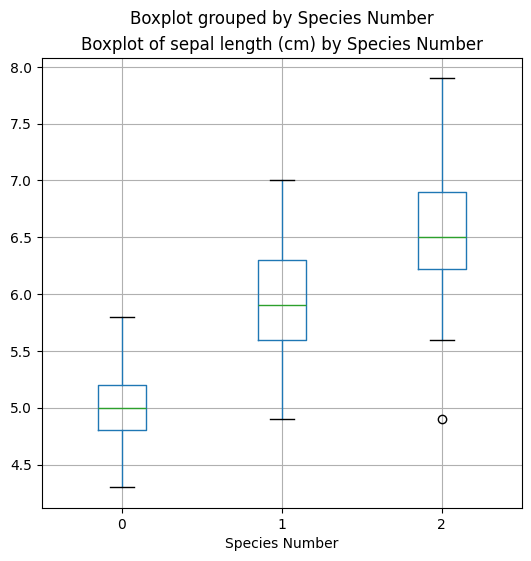

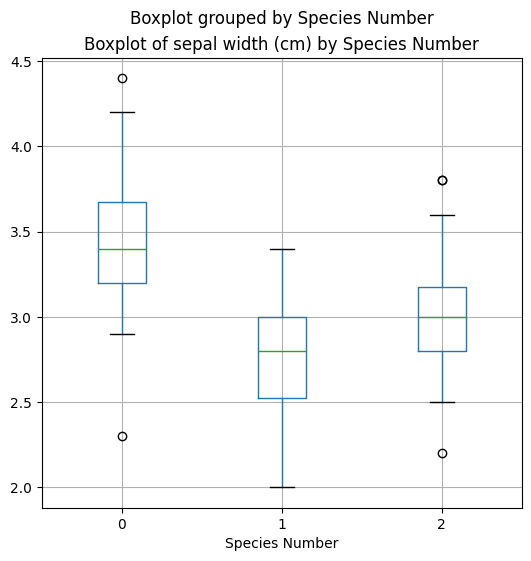

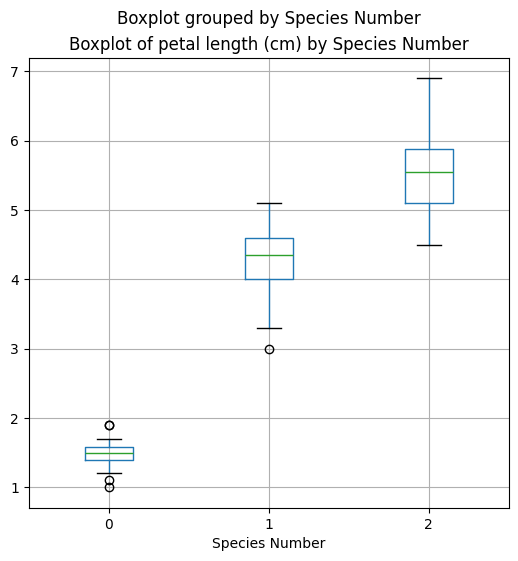

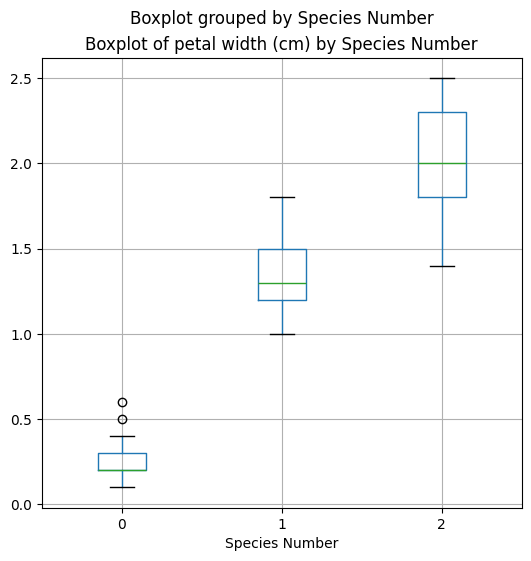

In [599]:
import matplotlib.pyplot as plt
%matplotlib inline

iris_features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
iris_label = 'Species Number'

for col in iris_features:
    df.boxplot(column=col, by=iris_label, figsize=(6, 6))
    plt.title(f'Boxplot of {col} by {iris_label}')

plt.show()

In [600]:
from sklearn.model_selection import train_test_split

i_x, i_y = df[iris_features], df[iris_label]
i_x_train, i_x_test, i_y_train, i_y_test = train_test_split(i_x,i_y, test_size=0.2, random_state=42)

print(f"Training set size: {len(i_x_train)}")
print(f"Test set size: {len(i_x_test)}")

Training set size: 120
Test set size: 30


In [601]:
from sklearn.linear_model import LogisticRegression

reg = 0.1

multi_model = LogisticRegression(C=1/reg, solver='lbfgs', max_iter=10000).fit(i_x_train, i_y_train)

print(multi_model)

LogisticRegression(C=10.0, max_iter=10000)


In [602]:
iris_pred = multi_model.predict(i_x_test)

print(f"Predictions: {iris_pred[:15]}")
print(f"Actual     : {i_y_test.values[:15]}")

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0]
Actual     : [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0]


In [603]:
from sklearn.metrics import classification_report

print(classification_report(i_y_test, iris_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [604]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

print(f"Overall Accuracy: {accuracy_score(i_y_test, iris_pred)}")
print(f"Overall Recall: {recall_score(i_y_test, iris_pred, average='macro')}")
print(f"Overall Precision: {precision_score(i_y_test, iris_pred, average='macro')}")

Overall Accuracy: 1.0
Overall Recall: 1.0
Overall Precision: 1.0


In [605]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(i_y_test, iris_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


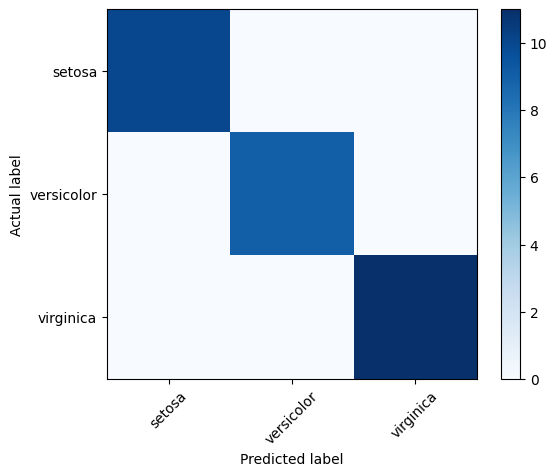

In [606]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

plt.colorbar()

tick_marks = np.arange(len(iris.target_names))

plt.xticks(tick_marks, iris.target_names, rotation=45)
plt.yticks(tick_marks, iris.target_names)

plt.xlabel('Predicted label')
plt.ylabel('Actual label')

plt.show()

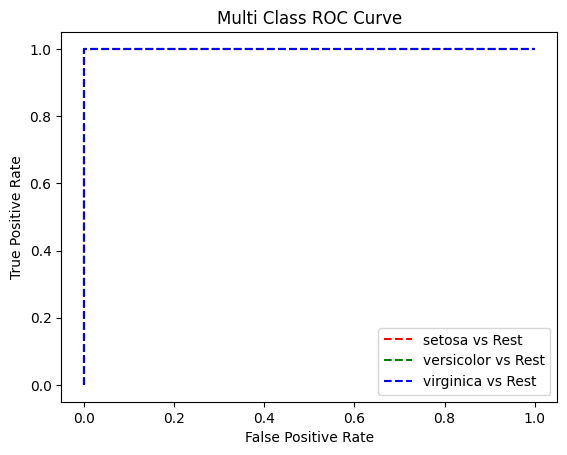

In [607]:
from sklearn.metrics import roc_curve, roc_auc_score

iris_prob = multi_model.predict_proba(i_x_test)

fpr = {}
tpr = {}
thresh = {}

for i in range(len(iris.target_names)):
    fpr[i], tpr[i], thresh[i] = roc_curve(i_y_test, iris_prob[:, i], pos_label=i)

plt.plot(fpr[0], tpr[0], linestyle='--', color='red', label=iris.target_names[0] + ' vs Rest')
plt.plot(fpr[1], tpr[1], linestyle='--', color='green', label=iris.target_names[1] + ' vs Rest')
plt.plot(fpr[2], tpr[2], linestyle='--', color='blue', label=iris.target_names[2] + ' vs Rest')

plt.title('Multi Class ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='best')
plt.show()

In [608]:
auc = roc_auc_score(i_y_test, iris_prob, multi_class='ovr')
print(f"AUC Score: {auc}")

AUC Score: 1.0


In [609]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC

feature_columns = [0, 1, 2, 3]
feature_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('preprocess', feature_transformer, feature_columns)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVC(probability=True))
])

multi_model = pipeline.fit(i_x_train, i_y_train)

print(multi_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('preprocess',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3])])),
                ('regressor', SVC(probability=True))])


Overall Accuracy: 1.0
Overall Recall: 1.0
Overall Precision: 1.0
Average AUC Score: 1.0


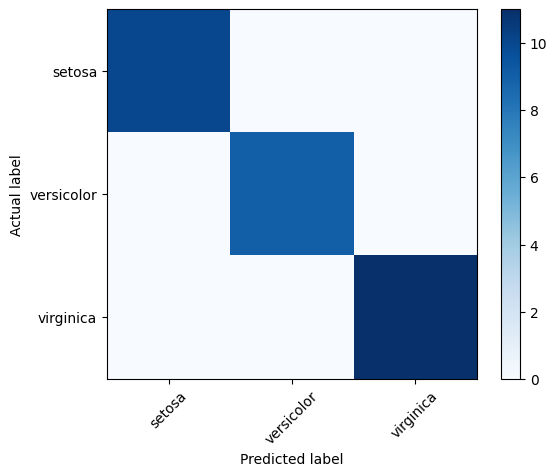

In [610]:
iris_pred = multi_model.predict(i_x_test)

iris_prob = multi_model.predict_proba(i_x_test)

print(f"Overall Accuracy: {accuracy_score(i_y_test, iris_pred)}")
print(f"Overall Recall: {recall_score(i_y_test, iris_pred, average='macro')}")
print(f"Overall Precision: {precision_score(i_y_test, iris_pred, average='macro')}")
print(f"Average AUC Score: {roc_auc_score(i_y_test, iris_prob, multi_class='ovr')}")

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(iris.target_names))
plt.xticks(tick_marks, iris.target_names, rotation=45)
plt.yticks(tick_marks, iris.target_names)
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.show()

In [611]:
import joblib

file_name = 'iris_model.pkl'
joblib.dump(multi_model, file_name)
print(f"Model saved to {file_name}")

Model saved to iris_model.pkl


In [612]:
multi_model = joblib.load(file_name)

feature_names = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
label = 'target'
x_new = pd.DataFrame([[6.0, 2.5, 4.0, 1.5]], columns=feature_names)
print(f"New sample: {x_new.iloc[0].values}")

iris_pred_new = multi_model.predict(x_new)[0]

print(f"Predicted class number: {iris_pred_new}")
print(f"Predicted class name: {iris.target_names[iris_pred_new]}")

New sample: [6.  2.5 4.  1.5]
Predicted class number: 1
Predicted class name: versicolor


In [613]:
x_new = pd.DataFrame([[5.2,3.4,1.6,0.2],
                      [6.7,3.1,5.6,2.4]], columns=feature_names)
print(f"New samples:\n{x_new}")

pred = multi_model.predict(x_new)

for prediction in pred:
    print(prediction, '(' + iris.target_names[prediction] + ')')

New samples:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.2               3.4                1.6               0.2
1                6.7               3.1                5.6               2.4
0 (setosa)
2 (virginica)


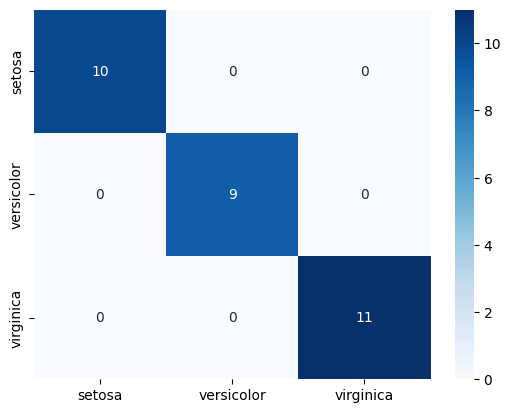

In [614]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(i_y_test, iris_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.show()

In [615]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(i_y_test, iris_pred)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 1.000


In [616]:
from sklearn.metrics import classification_report
print(classification_report(i_y_test, iris_pred, target_names=['setosa', 'versicolor', 'virginica']))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

